In [8]:

import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import data

%matplotlib inline

## Task 1 — Unsharp Masking

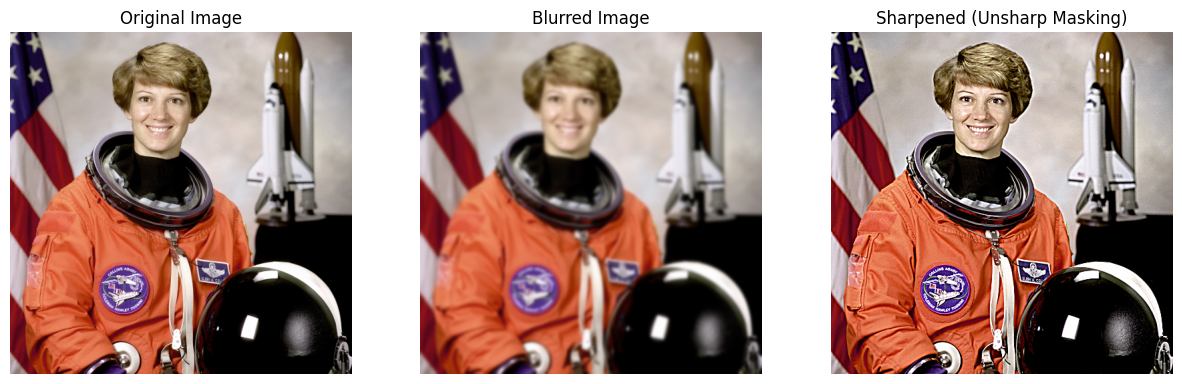

In [9]:
image = data.astronaut()

# Gaussian sigma (blur strength)
sigma = 2

# Sharpening strength
amount = 1.5

# Convert image to float32 for processing
image_float = image.astype(np.float32) / 255.0

# Apply Gaussian blur
blurred = cv2.GaussianBlur(image_float, (0, 0), sigmaX=sigma, sigmaY=sigma)

# Perform Unsharp Masking
sharpened = np.clip(image_float + amount * (image_float - blurred), 0, 1)

# Plot original, blurred, and sharpened images
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(image);      ax[0].set_title("Original Image");              ax[0].axis("off")
ax[1].imshow(blurred);    ax[1].set_title("Blurred Image");               ax[1].axis("off")
ax[2].imshow(sharpened);  ax[2].set_title("Sharpened (Unsharp Masking)"); ax[2].axis("off")
plt.show()

## Assessment Task 1

Kernel sum: 0.99999994


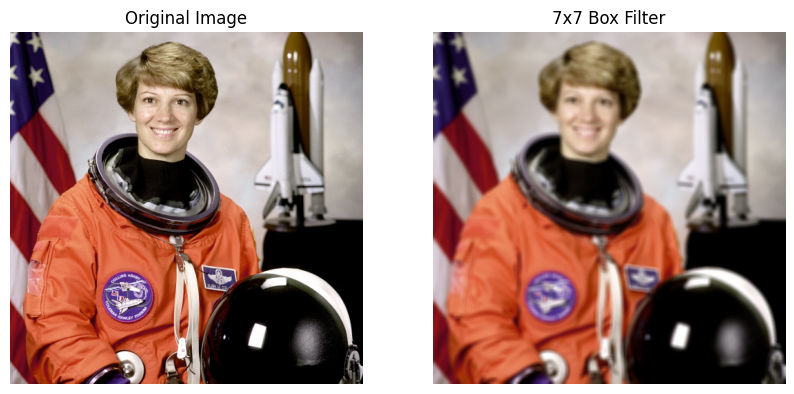

In [10]:

image = data.astronaut()

#  Build the 7x7 box kernel
kernel_box = np.ones((7, 7), dtype=np.float32) / 49.0
print("Kernel sum:", kernel_box.sum())

#  Apply convolution with filter2D
box_filtered = cv2.filter2D(image, -1, kernel_box)

# Plot
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(image);         ax[0].set_title("Original Image");   ax[0].axis("off")
ax[1].imshow(box_filtered);  ax[1].set_title("7x7 Box Filter");   ax[1].axis("off")
plt.show()

## Assessment Task 2

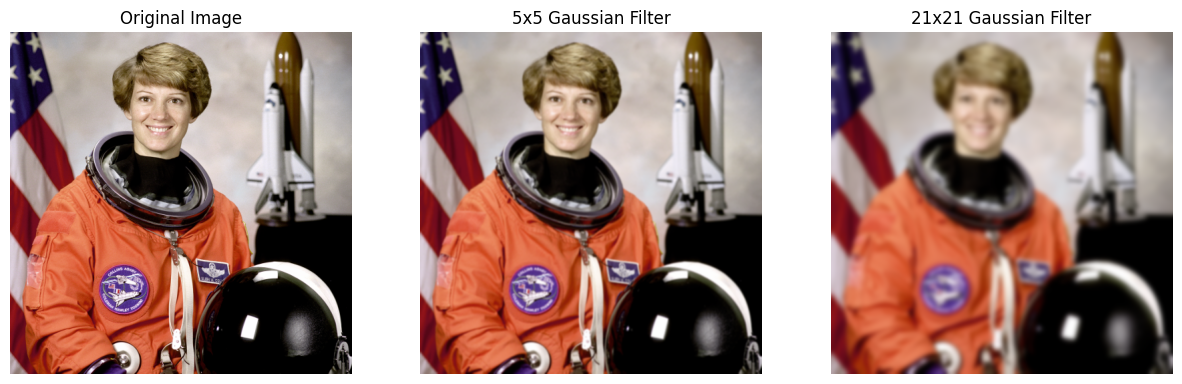

In [12]:

image = data.astronaut()

# 5x5 Gaussian kernel
kernel_5 = np.array([[1,  4,  6,  4, 1],
                     [4, 16, 24, 16, 4],
                     [6, 24, 36, 24, 6],
                     [4, 16, 24, 16, 4],
                     [1,  4,  6,  4, 1]], dtype=np.float32) / 256.0
gauss_5 = cv2.filter2D(image, -1, kernel_5)

# 21x21 Gaussian filter
gauss_21 = cv2.GaussianBlur(image, (21, 21), 0)

# Plot
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(image);     ax[0].set_title("Original Image");     ax[0].axis("off")
ax[1].imshow(gauss_5);   ax[1].set_title("5x5 Gaussian Filter");   ax[1].axis("off")
ax[2].imshow(gauss_21);  ax[2].set_title("21x21 Gaussian Filter"); ax[2].axis("off")
plt.show()

## Assessment Task 3

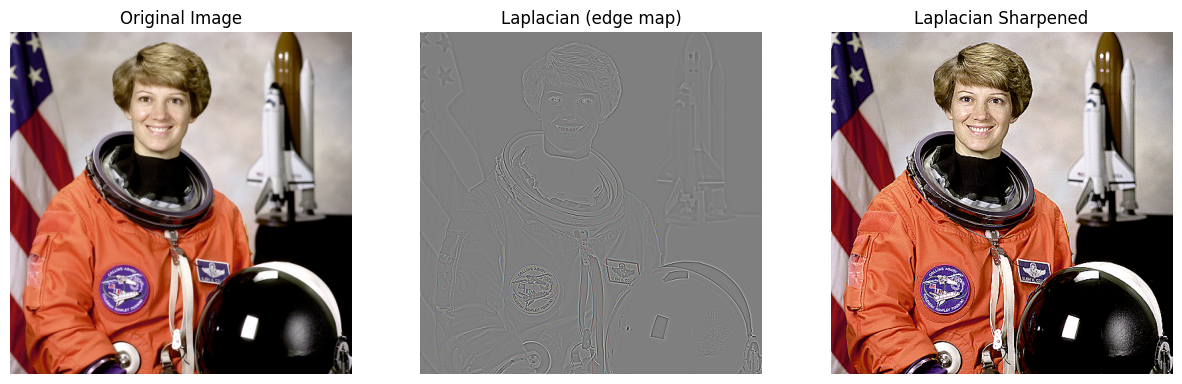

In [13]:

image = data.astronaut()

#  Convert to float32 in [0, 1]
image_float = image.astype(np.float32) / 255.0

# Apply the 3x3 Laplacian
laplacian = cv2.Laplacian(image_float, cv2.CV_32F, ksize=1)

#  Sharpen: original - laplacian
sharpened = np.clip(image_float - laplacian, 0, 1)

#  Plot the three images
lap_display = np.clip(laplacian * 0.5 + 0.5, 0, 1)

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(image);          ax[0].set_title("Original Image");          ax[0].axis("off")
ax[1].imshow(lap_display);    ax[1].set_title("Laplacian (edge map)");    ax[1].axis("off")
ax[2].imshow(sharpened);      ax[2].set_title("Laplacian Sharpened");     ax[2].axis("off")
plt.show()

## Q1 — Effect of Different Box Filter Sizes

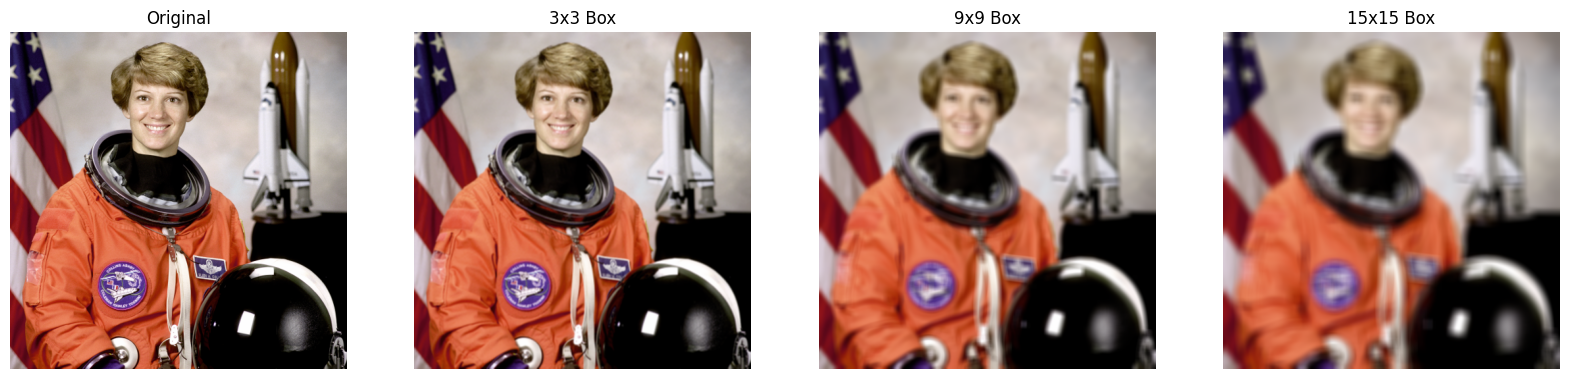

In [14]:
image = data.astronaut()

box_3  = cv2.blur(image, (3, 3))
box_9  = cv2.blur(image, (9, 9))
box_15 = cv2.blur(image, (15, 15))

fig, ax = plt.subplots(1, 4, figsize=(20, 5))
ax[0].imshow(image);   ax[0].set_title("Original");     ax[0].axis("off")
ax[1].imshow(box_3);   ax[1].set_title("3x3 Box");      ax[1].axis("off")
ax[2].imshow(box_9);   ax[2].set_title("9x9 Box");      ax[2].axis("off")
ax[3].imshow(box_15);  ax[3].set_title("15x15 Box");    ax[3].axis("off")
plt.show()

## Q2 — Median Filter: Removing Salt-and-Pepper Noise

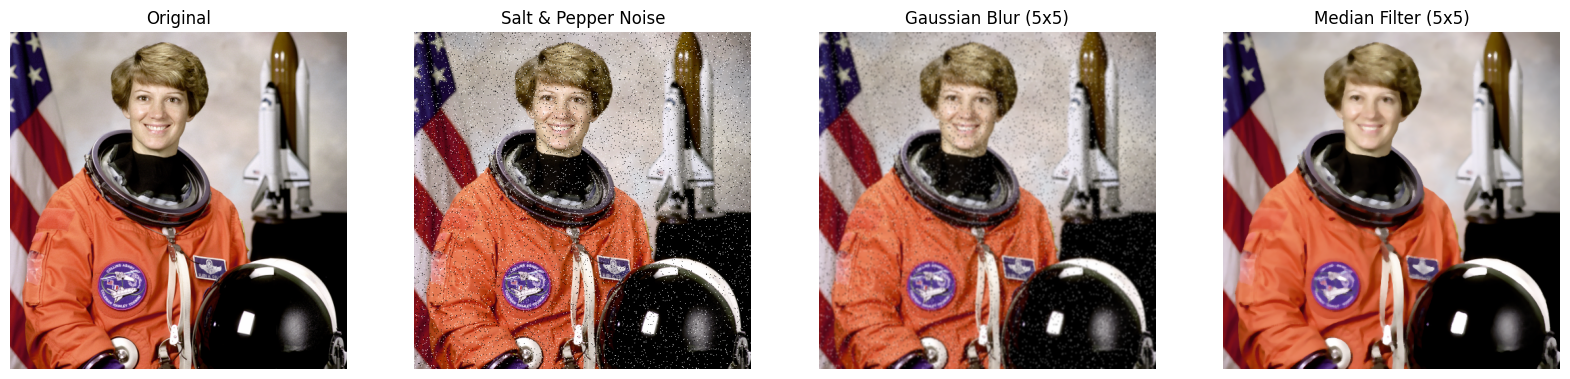

In [15]:
image = data.astronaut()

noisy = image.copy()
prob = 0.05
rnd = np.random.rand(image.shape[0], image.shape[1])
noisy[rnd < prob / 2] = 0
noisy[rnd > 1 - prob / 2] = 255


gaussian_result = cv2.GaussianBlur(noisy, (5, 5), 0)
median_result   = cv2.medianBlur(noisy, 5)

fig, ax = plt.subplots(1, 4, figsize=(20, 5))
ax[0].imshow(image);            ax[0].set_title("Original");                ax[0].axis("off")
ax[1].imshow(noisy);            ax[1].set_title("Salt & Pepper Noise");     ax[1].axis("off")
ax[2].imshow(gaussian_result);  ax[2].set_title("Gaussian Blur (5x5)");     ax[2].axis("off")
ax[3].imshow(median_result);    ax[3].set_title("Median Filter (5x5)");     ax[3].axis("off")
plt.show()

## Q3 — Bilateral Filter: Blurring While Keeping Edges Sharp

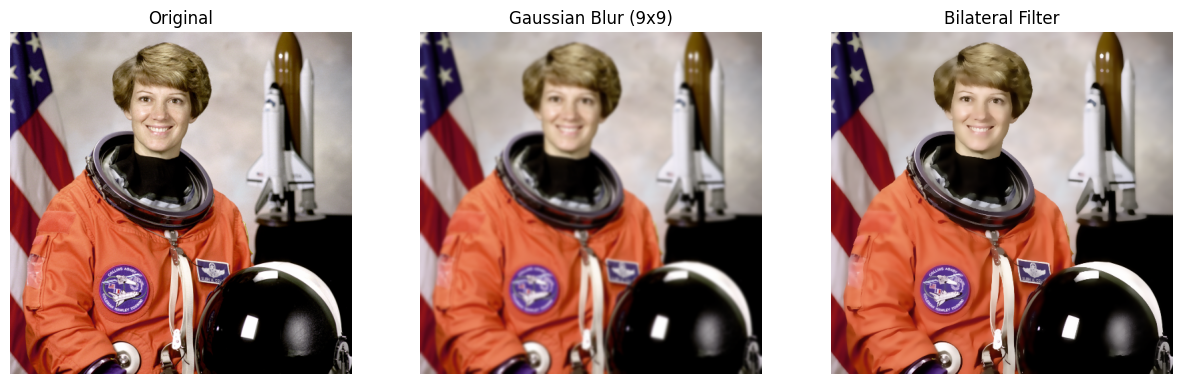

In [16]:
image = data.astronaut()

gaussian_result  = cv2.GaussianBlur(image, (9, 9), 0)

bilateral_result = cv2.bilateralFilter(image, d=9, sigmaColor=75, sigmaSpace=75)

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(image);             ax[0].set_title("Original");                 ax[0].axis("off")
ax[1].imshow(gaussian_result);   ax[1].set_title("Gaussian Blur (9x9)");      ax[1].axis("off")
ax[2].imshow(bilateral_result);  ax[2].set_title("Bilateral Filter");         ax[2].axis("off")
plt.show()